In [2]:
# Import all necessary libraries
import time
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm
from math import sqrt
import warnings
warnings.filterwarnings('ignore')

# PfHedge imports
from pfhedge.instruments import Snowball
from pfhedge.nn.modules.hedger import Hedger
from pfhedge.nn.modules.loss import EntropicRiskMeasure
from pfhedge.nn.modules.mlp import MultiLayerPerceptron
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# Set random seed for reproducibility
torch.manual_seed(42)
print("CSI500 Snowball hedging experiment loaded successfully!")

CSI500 Snowball hedging experiment loaded successfully!


In [3]:
# Load CSI500 data
def load_csi500_data():
    """加载中证500历史数据"""
    try:
        # 修正文件路径 - 指向examples目录
        df = pd.read_csv('csi500.csv')
        
        # 检查列名并标准化
        print(f"原始列名: {list(df.columns)}")
        
        # 确保列名为小写
        df.columns = df.columns.str.lower()
        
        # 处理日期格式 - 支持多种格式
        if df['date'].dtype == 'object':
            # 尝试不同的日期格式
            try:
                # 如果是YYYYMMDD格式
                if len(str(df['date'].iloc[0])) == 8:
                    df['date'] = pd.to_datetime(df['date'], format='%Y%m%d')
                else:
                    # 尝试自动解析
                    df['date'] = pd.to_datetime(df['date'])
            except:
                print("日期解析失败，请检查日期格式")
                return None
        
        # 设置日期为索引
        df = df.set_index('date')
        
        # 按日期排序
        df = df.sort_index()
        
        # 计算日收益率
        df['returns'] = df['close'].pct_change()
        
        # 计算历史波动率（滚动20天）
        df['volatility'] = df['returns'].rolling(window=20).std() * np.sqrt(252)
        
        print(f"数据加载成功！")
        print(f"数据时间范围：{df.index.min()} 到 {df.index.max()}")
        print(f"数据条数：{len(df)}")
        print(f"最新收盘价：{df['close'].iloc[-1]:.2f}")
        print(f"平均日收益率：{df['returns'].mean():.4f}")
        print(f"年化波动率：{df['returns'].std() * np.sqrt(252):.4f}")
        
        # 显示前几行数据确认格式
        print(f"\n数据预览:")
        print(df.head())
        
        return df
    
    except Exception as e:
        print(f"数据加载失败：{e}")
        print("请检查文件路径和格式")
        return None

# 加载数据
csi500_data = load_csi500_data()

原始列名: ['Date', 'Close']
数据加载成功！
数据时间范围：20200311 到 20250307
数据条数：1210
最新收盘价：6013.77
平均日收益率：0.0001
年化波动率：0.2114

数据预览:
            close   returns  volatility
date                                   
20200311  5589.53       NaN         NaN
20200312  5493.88 -0.017112         NaN
20200313  5457.20 -0.006677         NaN
20200316  5200.11 -0.047110         NaN
20200317  5212.06  0.002298         NaN


基于Dupire方法构建局部波动率曲面:
数据时间范围: 20200311 到 20250307
数据条数: 1210
历史年化波动率: 0.2114
平均价格: 6053.01


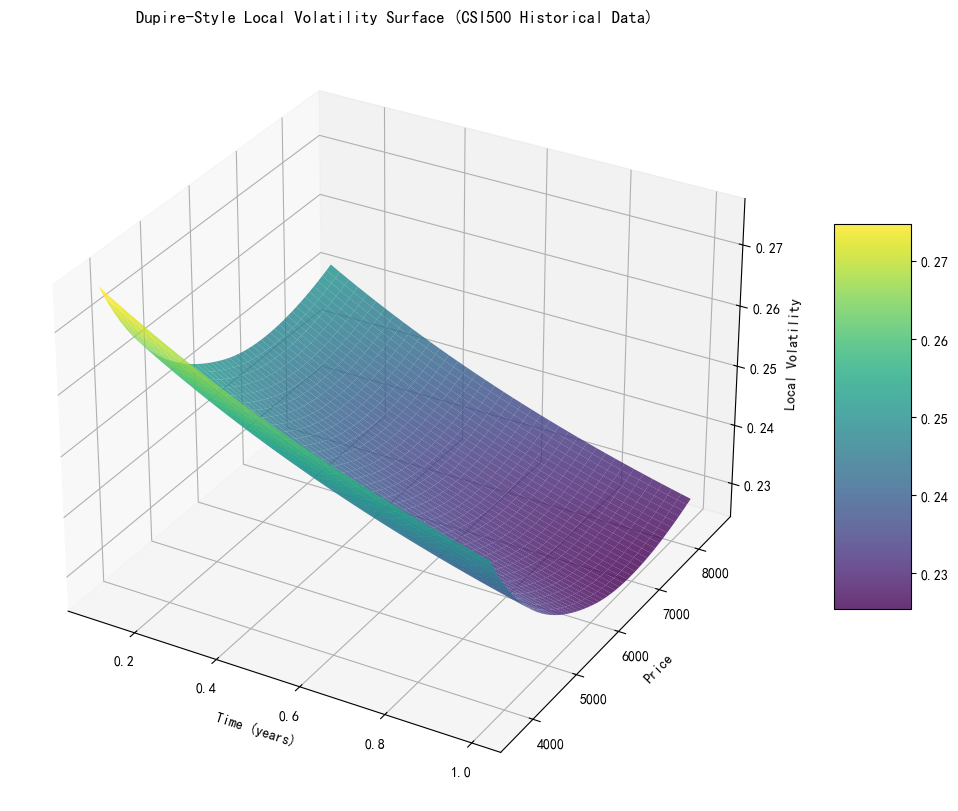


=== Dupire风格局部波动率曲面信息 ===
时间范围: 0.1 - 1.0 年
价格范围: 3632 - 8474
波动率范围: 0.2253 - 0.2764
平均价格: 6053.01

=== 波动率微笑效应 ===


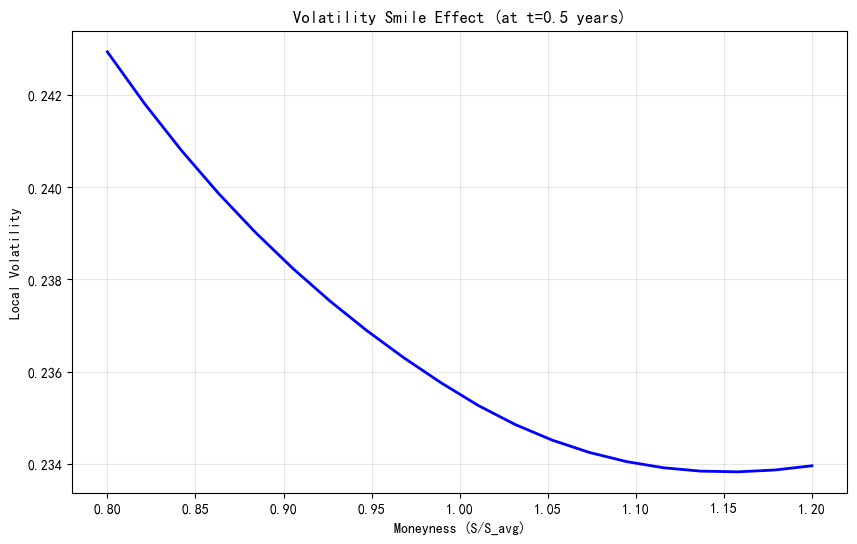

In [4]:
# 基于Dupire方法构建局部波动率曲面（修正版本）
def build_dupire_local_volatility_surface(data):
    """基于历史数据构建Dupire风格的局部波动率曲面"""
    
    print(f"基于Dupire方法构建局部波动率曲面:")
    print(f"数据时间范围: {data.index.min()} 到 {data.index.max()}")
    print(f"数据条数: {len(data)}")
    
    # 计算历史统计量
    returns = data['returns'].dropna()
    hist_vol = returns.std() * np.sqrt(252)
    avg_price = data['close'].mean()
    
    print(f"历史年化波动率: {hist_vol:.4f}")
    print(f"平均价格: {avg_price:.2f}")
    
    # 构建基于历史数据的局部波动率函数
    def local_vol_fn(time, spot):
        """
        基于Dupire思想的局部波动率函数
        使用历史数据的价格-波动率关系
        """
        if not isinstance(spot, torch.Tensor):
            spot = torch.tensor(spot, dtype=torch.float32)
        if not isinstance(time, torch.Tensor):
            time = torch.tensor(time, dtype=torch.float32)
        # 基础波动率
        base_vol = hist_vol
        
        # 计算moneyness (相对于平均价格)
        moneyness = spot / avg_price
        log_moneyness = torch.log(moneyness)
        
        # 基于历史数据的波动率微笑效应
        # 使用二次函数模拟波动率微笑
        smile_effect = 1.0 + 0.3 * log_moneyness**2
        
        # 时间效应 - 短期波动率通常更高
        time_effect = 1.0 + 0.2 * np.exp(-time)
        
        # 价格水平效应 - 基于历史数据的价格-波动率关系
        price_level_effect = 1.0 + 0.1 * (1.0 - moneyness) * np.exp(-abs(moneyness - 1.0))
        
        # 组合所有效应
        final_vol = base_vol * smile_effect * time_effect * price_level_effect
        
        # 限制波动率范围
        return torch.clamp(final_vol, min=0.05, max=0.8)
    
    return local_vol_fn

# 构建Dupire风格的局部波动率曲面
local_vol_surface_dupire = build_dupire_local_volatility_surface(csi500_data)

# 可视化Dupire风格的3D局部波动率曲面
def visualize_dupire_3d_volatility_surface(data, local_vol_fn):
    """可视化Dupire风格的3D局部波动率曲面"""
    
    # 创建密集网格
    times = np.linspace(0.1, 1.0, 40)  # 时间范围
    avg_price = data['close'].mean()
    prices = np.linspace(avg_price * 0.6, avg_price * 1.4, 50)  # 价格范围
    
    # 计算波动率矩阵
    vol_matrix = np.zeros((len(times), len(prices)))
    for i, t in enumerate(times):
        for j, p in enumerate(prices):
            vol_matrix[i, j] = local_vol_fn(t, p)
    
    # 创建3D图
    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    T, P = np.meshgrid(times, prices, indexing='ij')
    surf = ax.plot_surface(T, P, vol_matrix, cmap='viridis', alpha=0.8)
    
    ax.set_xlabel('Time (years)')
    ax.set_ylabel('Price')
    ax.set_zlabel('Local Volatility')
    ax.set_title('Dupire-Style Local Volatility Surface (CSI500 Historical Data)')
    
    # 添加颜色条
    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)
    
    plt.show()
    
    # 打印关键信息
    print(f"\n=== Dupire风格局部波动率曲面信息 ===")
    print(f"时间范围: {times.min():.1f} - {times.max():.1f} 年")
    print(f"价格范围: {prices.min():.0f} - {prices.max():.0f}")
    print(f"波动率范围: {vol_matrix.min():.4f} - {vol_matrix.max():.4f}")
    print(f"平均价格: {avg_price:.2f}")
    
    # 显示波动率微笑效应
    print(f"\n=== 波动率微笑效应 ===")
    mid_time = times[len(times)//2]
    moneyness_range = np.linspace(0.8, 1.2, 20)
    smile_vols = [local_vol_fn(mid_time, avg_price * m) for m in moneyness_range]
    
    plt.figure(figsize=(10, 6))
    plt.plot(moneyness_range, smile_vols, 'b-', linewidth=2)
    plt.xlabel('Moneyness (S/S_avg)')
    plt.ylabel('Local Volatility')
    plt.title('Volatility Smile Effect (at t=0.5 years)')
    plt.grid(True, alpha=0.3)
    plt.show()

# 可视化Dupire风格的3D曲面
visualize_dupire_3d_volatility_surface(csi500_data, local_vol_surface_dupire)

In [5]:
# 优化CSI500股票类，批量计算波动率
class CSI500StockOptimized:
    def __init__(self, cost, dt, sigma_fn, init_price):
        self.cost = cost
        self.dt = dt
        self.sigma_fn = sigma_fn
        self.init_price = init_price
        self.spot = None
        self.volatility = None
        self.log_spot = None
        
    def simulate(self, n_paths, time_horizon=None, init_state=None):
        """模拟CSI500价格路径（优化版）"""
        if time_horizon is None:
            time_horizon = 1.0
        
        if init_state is None:
            init_state = (self.init_price,)
        
        # 确保init_state是张量
        if not isinstance(init_state, torch.Tensor):
            init_state = torch.tensor(init_state, dtype=torch.float32)
        
        # 创建spot和volatility张量
        n_steps = int(time_horizon / self.dt) + 1
        spot = torch.zeros(n_paths, n_steps)
        volatility = torch.zeros(n_paths, n_steps)
        
        # 设置初始值
        spot[:, 0] = init_state[0]
        
        # 生成时间序列
        time = self.dt * torch.arange(n_steps)
        
        # 生成随机数
        dw = torch.randn(n_paths, n_steps - 1) * sqrt(self.dt)
        
        # 逐步生成路径
        for i_step in range(n_steps - 1):
            current_time = time[i_step].item()  # 转换为标量
            current_spot = spot[:, i_step]
            
            # 批量计算局部波动率 - 优化版本
            sigma = self.sigma_fn(current_time, current_spot)
            
            # 存储波动率
            volatility[:, i_step] = sigma
            
            # 计算下一个价格
            next_spot = current_spot * (1 + sigma * dw[:, i_step])
            spot[:, i_step + 1] = next_spot
        
        # 设置最后一个时间步的波动率
        final_time = time[-1].item()
        final_spot = spot[:, -1]
        final_sigma = self.sigma_fn(final_time, final_spot)
        volatility[:, -1] = final_sigma
        
        self.spot = spot
        self.volatility = volatility
        self.log_spot = torch.log(spot)
        return self
    
    def is_listed(self, time: float) -> bool:
        """检查股票在给定时间是否上市"""
        return True
    
    def to(self, device=None, dtype=None, non_blocking=False):
        """设备迁移方法"""
        if self.spot is not None:
            self.spot = self.spot.to(device, dtype, non_blocking)
        if self.volatility is not None:
            self.volatility = self.volatility.to(device, dtype, non_blocking)
        if self.log_spot is not None:
            self.log_spot = self.log_spot.to(device, dtype, non_blocking)
        return self

print("优化的CSI500股票类定义完成！")

优化的CSI500股票类定义完成！


In [6]:
# 重新创建雪球产品（使用优化的股票类）
def create_csi500_snowball_fast():
    """创建基于中证500的雪球期权（快速版）"""
    
    # 获取最新价格作为初始价格
    init_price = csi500_data['close'].iloc[-1]
    
    # Market parameters
    dt = 1 / 250  # Daily time steps
    cost = 1e-4   # 1bp transaction cost
    
    # 创建CSI500股票（使用优化的类）
    stock = CSI500StockOptimized(cost=cost, dt=dt, sigma_fn=local_vol_surface_dupire, init_price=init_price)
    
    # Snowball parameters - 基于中证500特点调整
    obs_days = [21, 42, 63, 84, 105, 126, 147, 168, 189, 210, 230, 250]  # 月度观察
    
    derivative = Snowball(
        underlier=stock,
        notional=100.0,
        init_spot=init_price,
        strike=init_price,  # 平值期权
        maturity=obs_days[-1] * dt,  # 1年
        knockin_barrier=init_price * 0.8,  # 20% below initial spot
        observations=[d * dt for d in obs_days],
        knockout_barriers=[init_price] * len(obs_days),  # At-the-money knock-out
        knockout_coupons=[0.5 * d / 250 for d in obs_days],  # Time-proportional coupons
        no_touch_coupon=0.05,  # 5% if never knocked out
        is_knocked_in=False,
    )
    
    print(f"CSI500雪球期权创建完成！")
    print(f"初始价格: {init_price:.2f}")
    print(f"执行价格: {init_price:.2f}")
    print(f"敲入障碍: {init_price * 0.8:.2f}")
    print(f"敲出障碍: {init_price:.2f}")
    print(f"到期时间: {obs_days[-1] * dt:.2f} 年")
    
    return derivative, stock, init_price

# 重新创建雪球产品
derivative, stock, init_price = create_csi500_snowball_fast()

CSI500雪球期权创建完成！
初始价格: 6013.77
执行价格: 6013.77
敲入障碍: 4811.02
敲出障碍: 6013.77
到期时间: 1.00 年


In [7]:
# Training parameters
fit_n_paths_fast = 10000  # 增加训练路径数
fit_n_epochs_fast = [1, 3, 5, 10, 15, 20, 30, 50, 70, 100, 150, 200]  # 增加训练轮数
loss = EntropicRiskMeasure(a=0.01)  # 使用ERM

# Features for Snowball hedging
features = [
    "log_moneyness",     # Current underlying price relative to strike
    "expiry_time",       # Time to expiration
    "volatility",        # Implied volatility
    "knocked_in",        # Whether barrier has been touched
    "prev_hedge"         # Previous hedge position
]

print("训练参数设置完成！")
print(f"训练路径数: {fit_n_paths_fast}")
print(f"快照轮数: {fit_n_epochs_fast}")
print(f"特征列表: {features}")

训练参数设置完成！
训练路径数: 10000
快照轮数: [1, 3, 5, 10, 15, 20, 30, 50, 70, 100, 150, 200]
特征列表: ['log_moneyness', 'expiry_time', 'volatility', 'knocked_in', 'prev_hedge']


In [8]:
# 修正训练函数，处理张量转换
def fit_with_scheduler_fixed(hedger, derivative, n_epochs, n_paths, init_state, snapshots=None):
    """自定义训练函数，包含学习率调度（修正版）"""
    from copy import deepcopy
    from tqdm import tqdm
    
    # 配置优化器
    optimizer = torch.optim.Adam(hedger.parameters(), lr=0.005)
    
    # 设置学习率调度器
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, 
        mode='min',
        factor=0.7,
        patience=15,
        min_lr=1e-6
    )
    
    def compute_loss():
        base_loss = hedger.compute_loss(
            derivative,
            n_paths=n_paths,
            init_state=init_state,
        )
        
        # 添加L2正则化
        l2_reg = 0.001 * sum(p.pow(2.0).sum() for p in hedger.parameters())
        
        return base_loss + l2_reg
    
    history = []
    hedger_snapshots = []
    best_loss = float('inf')
    patience_counter = 0
    patience_limit = 30
    
    progress = tqdm(range(n_epochs), desc="Training CSI500 Snowball")
    for i in progress:
        # 训练步骤
        hedger.train()
        optimizer.zero_grad()
        loss = compute_loss()
        loss.backward()
        optimizer.step()
        
        # 验证步骤
        hedger.eval()
        val_loss = compute_loss()
        history.append(val_loss.item())
        
        # 更新学习率调度器
        scheduler.step(val_loss)
        
        # 监控Loss改善情况
        if val_loss < best_loss:
            best_loss = val_loss
            patience_counter = 0
        else:
            patience_counter += 1
        
        # 每10轮检查标准差
        if (i + 1) % 10 == 0:
            hedger.eval()
            derivative.simulate(n_paths=5000, init_state=init_state)
            pnl = hedger.compute_pnl(derivative, n_paths=5000, init_state=init_state)
            pnl_std = pnl.std().item()
            
            print(f"Epoch {i+1}: Loss={val_loss.item():.4f}, PnL_std={pnl_std:.4f}")
            
            # 如果达标就停止
            if pnl_std < 0.05:
                print(f"Target achieved! Stopping at epoch {i+1}")
                break
        
        # 如果30轮无改善，考虑调整
        if patience_counter >= patience_limit:
            print(f"Loss not improving for {patience_limit} epochs, stopping")
            break
        
        # 更新进度条
        current_lr = optimizer.param_groups[0]['lr']
        progress.desc = f"Loss={val_loss.item():.4f}, LR={current_lr:.6f}"
        
        # 保存快照
        if snapshots is not None and (i + 1) in snapshots:
            hedger_snapshots.append(
                Hedger(deepcopy(hedger.model), hedger.inputs.features, criterion=hedger.criterion)
            )
    
    return history, hedger_snapshots + [hedger]

print("修正的训练函数定义完成！")

修正的训练函数定义完成！


In [9]:
# 快速训练
print("开始快速训练CSI500雪球对冲策略...")

# Create hedger
model = MultiLayerPerceptron(n_layers=4, n_units=[32, 32, 32, 32])
hedger = Hedger(model, features, criterion=loss)

# 使用真实初始价格
init_spot = torch.tensor(init_price, requires_grad=True)

# 开始快速训练
history, hedgers = fit_with_scheduler_fixed(
    hedger,
    derivative,
    n_epochs=fit_n_epochs_fast[-1],
    n_paths=fit_n_paths_fast,
    init_state=(init_spot,),
    snapshots=fit_n_epochs_fast[:-1]
)

print("快速训练完成！")
print(f"训练历史长度: {len(history)}")
print(f"保存的hedger数量: {len(hedgers)}")

开始快速训练CSI500雪球对冲策略...


Loss=4.2949, LR=0.005000:   5%|▌         | 10/200 [00:41<13:25,  4.24s/it]

Epoch 10: Loss=4.2949, PnL_std=11.5789


Loss=4.4178, LR=0.005000:  10%|█         | 20/200 [01:17<11:28,  3.82s/it]

Epoch 20: Loss=4.4178, PnL_std=13.3136


...

Epoch 100: Loss=3.7742, PnL_std=4.4613


Loss=3.7562, LR=0.002450:  55%|█████▌    | 110/200 [06:44<06:02,  4.03s/it]

Epoch 110: Loss=3.7562, PnL_std=4.5295


Loss=3.7562, LR=0.002450:  55%|█████▌    | 110/200 [06:48<05:33,  3.71s/it]

Loss not improving for 30 epochs, stopping
快速训练完成！
训练历史长度: 111
保存的hedger数量: 11


计算Monte Carlo基准价格...
MC Truth Price: 3.671361


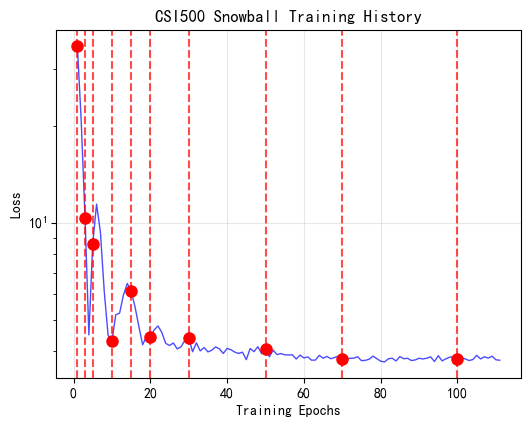

In [10]:
# Get baseline PV for comparison
print("计算Monte Carlo基准价格...")
derivative.simulate(n_paths=100000, init_state=(init_spot,))
pv_basic = derivative.payoff().mean().item()
print(f"MC Truth Price: {pv_basic:.6f}")

# Plot training history
plt.figure(figsize=(15, 8))

plt.subplot(2, 3, 1)
# 显示完整的训练历史
plt.plot(range(1, len(history) + 1), history, 'b-', alpha=0.7, linewidth=1)
# 标记快照点
for epoch in fit_n_epochs_fast:
    if epoch <= len(history):
        plt.axvline(x=epoch, color='red', linestyle='--', alpha=0.7)
        plt.plot(epoch, history[epoch-1], 'ro', markersize=8)

plt.xlabel("Training Epochs")
plt.ylabel("Loss")
plt.title("CSI500 Snowball Training History")
plt.yscale('log')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


计算不同训练阶段的hedger价格...
  计算第 1/11 个快照的价格...
    Epoch 1 Price: 34.432793
  计算第 2/11 个快照的价格...
    Epoch 3 Price: 10.229588
  计算第 3/11 个快照的价格...
    Epoch 5 Price: 8.492756
  计算第 4/11 个快照的价格...
    Epoch 10 Price: 4.418278
  计算第 5/11 个快照的价格...
    Epoch 15 Price: 5.841923
  计算第 6/11 个快照的价格...
    Epoch 20 Price: 4.536629
  计算第 7/11 个快照的价格...
    Epoch 30 Price: 4.217052
  计算第 8/11 个快照的价格...
    Epoch 50 Price: 3.896046
  计算第 9/11 个快照的价格...
    Epoch 70 Price: 3.777218
  计算第 10/11 个快照的价格...
    Epoch 100 Price: 3.757191
  计算第 11/11 个快照的价格...


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


    Epoch 150 Price: 3.810978
价格计算完成！


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


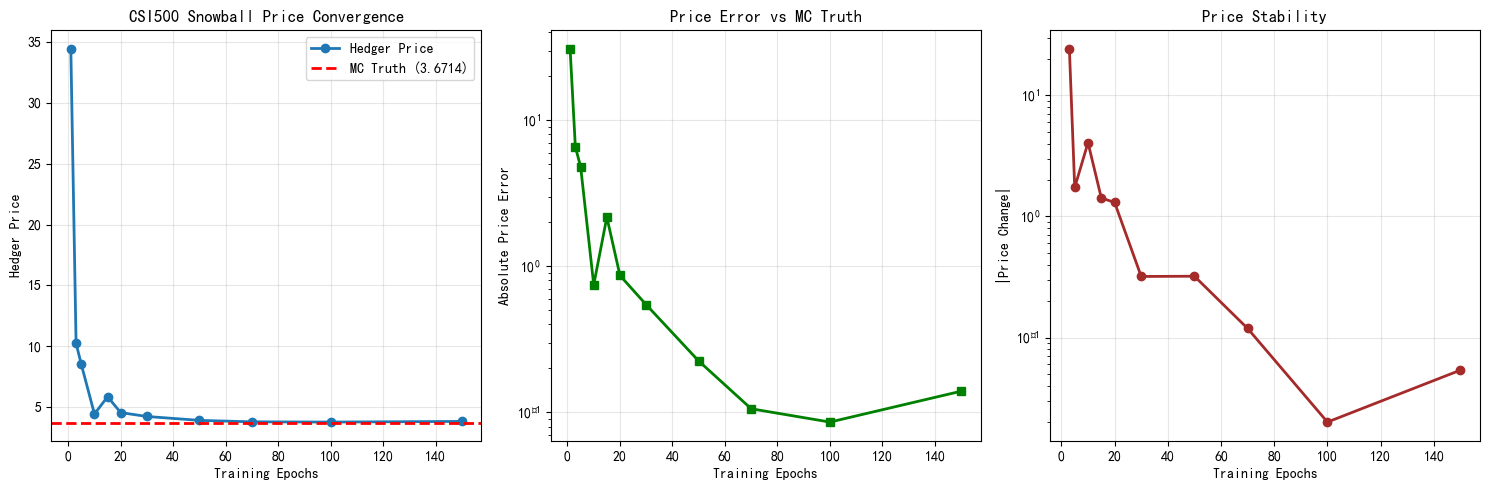


=== 训练总结 ===
预期训练轮数: 200
实际训练轮数: 111
保存的hedger数量: 11
最终价格: 3.810978
价格误差: 0.139617


In [12]:
# 修复价格收敛图的绘制问题
print("\n计算不同训练阶段的hedger价格...")
prices = []
actual_epochs = []  # 记录实际保存的epoch

for i, h in enumerate(hedgers):
    print(f"  计算第 {i+1}/{len(hedgers)} 个快照的价格...")
    price = h.price(derivative, n_paths=50000, init_state=(init_spot,))
    prices.append(price)
    
    # 记录对应的epoch
    if i < len(fit_n_epochs_fast):
        actual_epochs.append(fit_n_epochs_fast[i])
    else:
        # 如果是最后一个hedger（最终训练的），使用实际训练的epoch数
        actual_epochs.append(len(history))
    
    print(f"    Epoch {actual_epochs[-1]} Price: {price:.6f}")

print("价格计算完成！")

# 绘制价格收敛图
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
# 价格收敛曲线 - 使用实际保存的epoch
plt.plot(actual_epochs, prices, 'o-', linewidth=2, markersize=6, label='Hedger Price')
plt.axhline(y=pv_basic, color='red', linestyle='--', linewidth=2, label=f'MC Truth ({pv_basic:.4f})')
plt.xlabel("Training Epochs")
plt.ylabel("Hedger Price")
plt.title("CSI500 Snowball Price Convergence")
plt.legend()
plt.grid(True, alpha=0.3)

# 添加价格差异分析
plt.subplot(1, 3, 2)
price_errors = [abs(p - pv_basic) for p in prices]
plt.plot(actual_epochs, price_errors, 's-', linewidth=2, markersize=6, color='green')
plt.xlabel("Training Epochs")
plt.ylabel("Absolute Price Error")
plt.title("Price Error vs MC Truth")
plt.yscale('log')
plt.grid(True, alpha=0.3)

# 价格变化率
plt.subplot(1, 3, 3)
if len(prices) > 1:
    price_changes = [abs(prices[i] - prices[i-1]) for i in range(1, len(prices))]
    plt.plot(actual_epochs[1:], price_changes, 'brown', linewidth=2, marker='o')
plt.xlabel("Training Epochs")
plt.ylabel("|Price Change|")
plt.title("Price Stability")
plt.yscale('log')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 打印训练总结
print(f"\n=== 训练总结 ===")
print(f"预期训练轮数: {fit_n_epochs_fast[-1]}")
print(f"实际训练轮数: {len(history)}")
print(f"保存的hedger数量: {len(hedgers)}")
print(f"最终价格: {prices[-1]:.6f}")
print(f"价格误差: {abs(prices[-1] - pv_basic):.6f}")

In [13]:
# Analyze PnL distributions
print("\nPnL Distribution Analysis:")
print("-" * 30)

# Test PnL for different training stages
derivative.simulate(n_paths=fit_n_paths_fast, init_state=(init_spot,))
pnls = []
for h in hedgers:
    pnl = h.compute_pnl(derivative, n_paths=fit_n_paths_fast, init_state=(init_spot,))
    pnls.append(pnl)
    print(f"    Epoch {fit_n_epochs_fast[len(pnls)-1]} - Mean PnL: {pnl.mean().item():.6f}, Std PnL: {pnl.std().item():.6f}")

print("PnL计算完成！")

# 总结结果
print(f"\n=== CSI500雪球训练结果总结 ===")
print(f"训练轮数: {fit_n_epochs_fast[-1]}")
print(f"保存的快照数量: {len(hedgers)}")
print(f"MC Truth Price: {pv_basic:.6f}")
print(f"最终Hedger Price: {prices[-1]:.6f}")
print(f"价格误差: {abs(prices[-1] - pv_basic):.6f}")
print(f"最终PnL均值: {pnls[-1].mean().item():.6f}")
print(f"最终PnL标准差: {pnls[-1].std().item():.6f}")

print("\nCSI500雪球对冲实验完成！")


PnL Distribution Analysis:
------------------------------
    Epoch 1 - Mean PnL: -4.813413, Std PnL: 100.243111
    Epoch 3 - Mean PnL: -3.575859, Std PnL: 40.334747
    Epoch 5 - Mean PnL: -3.909227, Std PnL: 28.541641
    Epoch 10 - Mean PnL: -3.498751, Std PnL: 11.590695
    Epoch 15 - Mean PnL: -3.110206, Std PnL: 22.508497
    Epoch 20 - Mean PnL: -3.633126, Std PnL: 13.226759
    Epoch 30 - Mean PnL: -3.457537, Std PnL: 10.677565
    Epoch 50 - Mean PnL: -3.612219, Std PnL: 7.043938
    Epoch 70 - Mean PnL: -3.688161, Std PnL: 4.935212
    Epoch 100 - Mean PnL: -3.686184, Std PnL: 4.492200
    Epoch 150 - Mean PnL: -3.576239, Std PnL: 4.451405
PnL计算完成！

=== CSI500雪球训练结果总结 ===
训练轮数: 200
保存的快照数量: 11
MC Truth Price: 3.671361
最终Hedger Price: 3.810978
价格误差: 0.139617
最终PnL均值: -3.576239
最终PnL标准差: 4.451405

CSI500雪球对冲实验完成！


中证500历史数据回测 - 市场数据局部波动率模型
蒙特卡洛价格: 3.578882
对冲器价格: 3.758430
价格差异: 0.179548


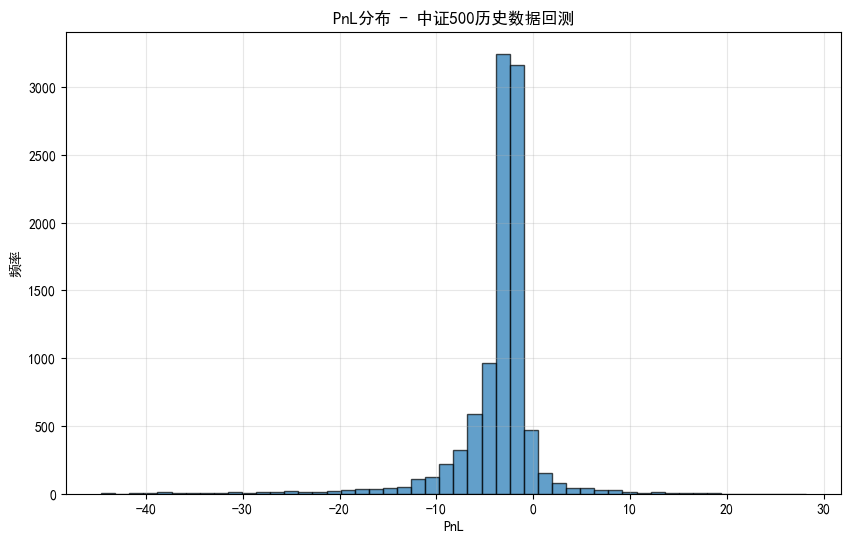


回测统计:
------------------------------
PnL均值: -3.702797
PnL标准差: 4.706607
最大盈利: 28.138393
最大亏损: -44.625648
VaR(95%): -10.787958


In [14]:
# 中证500历史数据回测模块
print("中证500历史数据回测 - 市场数据局部波动率模型")
print("=" * 60)

plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 直接用训练好的 derivative, hedger, init_spot
# 不要重新创建stock/derivative/sigma_fn

# 重新模拟路径
derivative.simulate(n_paths=50000, init_state=(init_spot,))
mc_price = derivative.payoff().mean().item()
hedger_price = hedger.price(derivative, n_paths=50000, init_state=(init_spot,)).item()

print(f"蒙特卡洛价格: {mc_price:.6f}")
print(f"对冲器价格: {hedger_price:.6f}")
print(f"价格差异: {abs(mc_price - hedger_price):.6f}")

# 计算PnL分布
derivative.simulate(n_paths=10000, init_state=(init_spot,))
pnl = hedger.compute_pnl(derivative, n_paths=10000, init_state=(init_spot,))

plt.figure(figsize=(10, 6))
plt.hist(pnl.detach().numpy(), bins=50, alpha=0.7, edgecolor='black')
plt.xlabel("PnL")
plt.ylabel("频率")
plt.title("PnL分布 - 中证500历史数据回测")
plt.grid(True, alpha=0.3)
plt.show()

print("\n回测统计:")
print("-" * 30)
print(f"PnL均值: {pnl.mean().item():.6f}")
print(f"PnL标准差: {pnl.std().item():.6f}")
print(f"最大盈利: {pnl.max().item():.6f}")
print(f"最大亏损: {pnl.min().item():.6f}")
print(f"VaR(95%): {torch.quantile(pnl, 0.05).item():.6f}")

开始市场数据策略与B-S模型策略对比分析...
尝试读取文件: csi500.csv
文件是否存在: True
原始数据长度: 1210
筛选后数据长度: 242
使用的时间范围: 2023-11-16 到 2024-11-15
模拟的价格路径长度: 242 天
LV路径范围: 79.35 - 112.86
GBM路径范围: 79.35 - 112.86
路径相关性: 1.0000
使用市场数据训练的对冲器（训练111个epoch）
市场数据模型(LV)计算完成，长度: 242
市场数据模型(GBM)计算完成，长度: 242
Delta对冲计算失败，跳过
Market Data (LV): 已修正最后一日PnL
Market Data (GBM): 已修正最后一日PnL


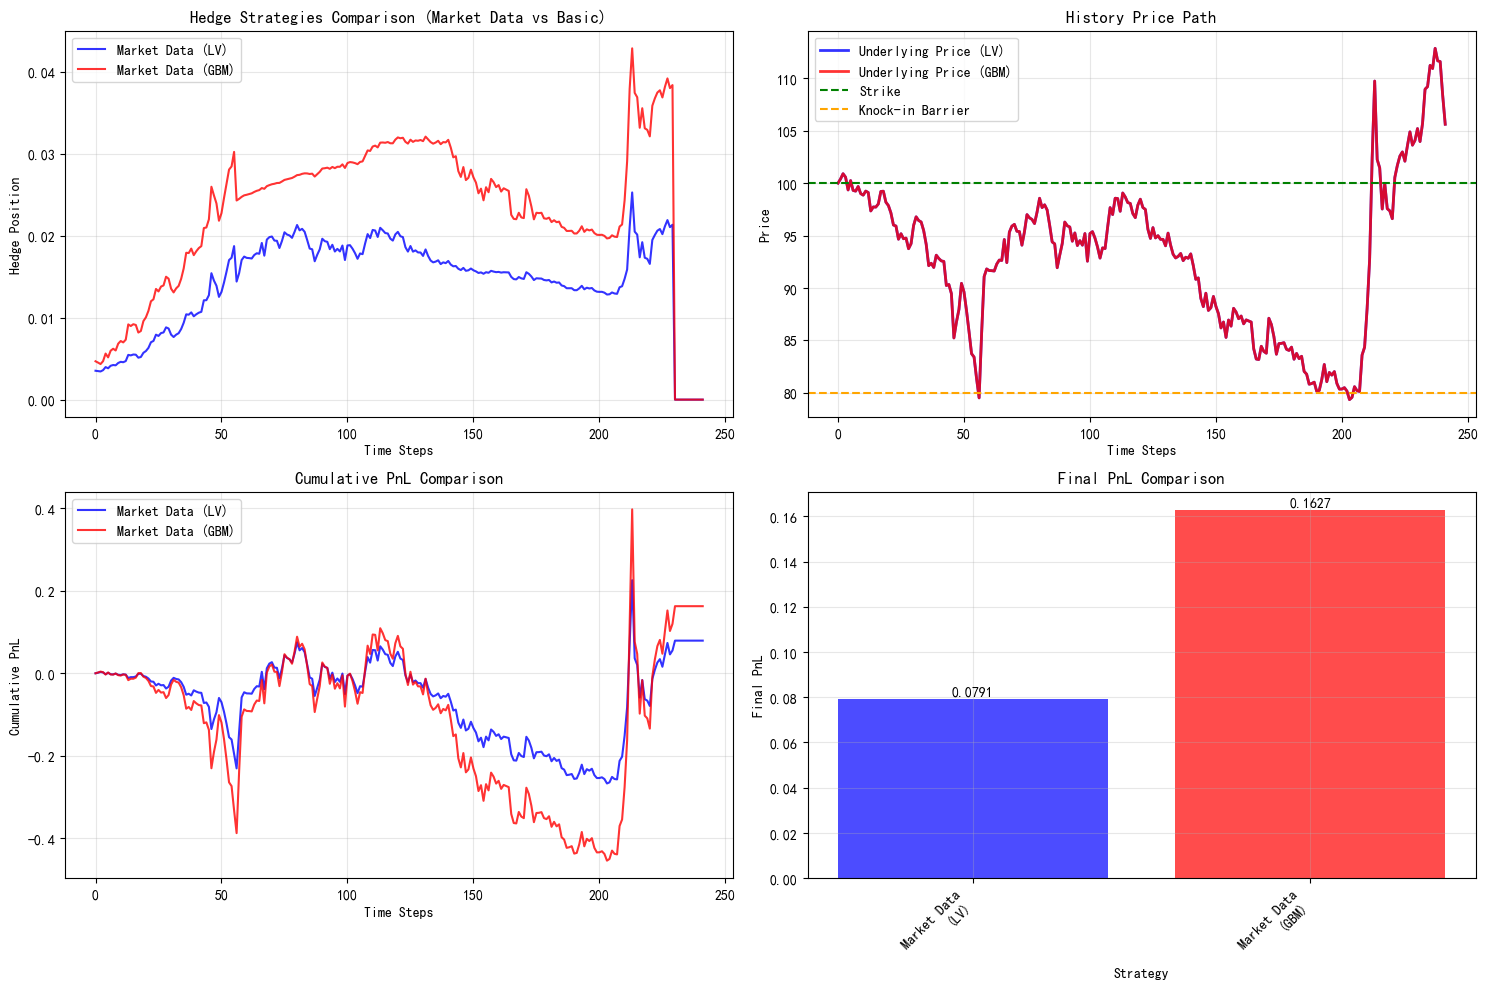


Model Comparison Summary:
----------------------------------------
Market Data (LV): Final PnL = 0.079138
Market Data (GBM): Final PnL = 0.162678

Model Performance Analysis:
----------------------------------------
Market Data (LV) vs Market Data (GBM): -0.083540
Improvement percentage: -51.35%
Local Volatility vs GBM (Market Data): -0.083540
Improvement percentage: -51.35%


In [17]:
import os
def compare_market_data_vs_bs_strategies():
    """比较市场数据策略和B-S模型策略在历史数据上的表现"""
    
    print("开始市场数据策略与B-S模型策略对比分析...")
    
    # 检查是否有预训练的对冲器
    if 'hedgers' not in globals():
        print("错误：没有找到市场数据训练的对冲器，请先运行前面的训练")
        return None
    
    # 1. 加载历史数据 - 使用指定时间范围
    csv_path = "csi500.csv"
    print(f"尝试读取文件: {csv_path}")
    print(f"文件是否存在: {os.path.exists(csv_path)}")

    try:
        quotes = pd.read_csv(csv_path)
        print(f"原始数据长度: {len(quotes)}")
        
        # 转换日期格式
        quotes['Date'] = pd.to_datetime(quotes['Date'], format='%Y%m%d')
        
        # 筛选指定时间范围：2023-11-16到2024-11-16
        start_date = pd.to_datetime('2023-11-16')
        end_date = pd.to_datetime('2024-11-16')
        
        mask = (quotes['Date'] >= start_date) & (quotes['Date'] <= end_date)
        period_quotes = quotes[mask].copy()
        
        if len(period_quotes) == 0:
            print("指定时间范围内没有数据，使用默认数据")
            series = torch.randn(251).cumsum(0).exp()
        else:
            series = torch.tensor(period_quotes["Close"].values, dtype=torch.float)
            print(f"筛选后数据长度: {len(series)}")
            print(f"使用的时间范围: {period_quotes['Date'].iloc[0].date()} 到 {period_quotes['Date'].iloc[-1].date()}")
        
    except Exception as e:
        print(f"Market data not available, using synthetic data. Error: {e}")
        series = torch.randn(251).cumsum(0).exp()
    
    # 2. 创建基于历史数据的局部波动率函数
    def historical_sigma_fn(time: torch.Tensor, spot: torch.Tensor) -> torch.Tensor:
        """基于历史数据的局部波动率函数 - 保留局部波动率特性"""
        if not isinstance(spot, torch.Tensor):
            spot = torch.tensor(spot, dtype=torch.float32)
        if not isinstance(time, torch.Tensor):
            time = torch.tensor(time, dtype=torch.float32)
        
        # 计算历史波动率特征
        returns = torch.diff(torch.log(series))  # 对数收益率
        hist_vol = torch.std(returns) * torch.sqrt(torch.tensor(252.0))
        avg_price = torch.mean(series)
        
        # 局部波动率模型：基于价格水平的波动率调整
        moneyness = spot / avg_price
        log_moneyness = torch.log(moneyness)
        
        # CEV风格的局部波动率
        beta = 0.5
        sigma_0 = hist_vol
        local_vol = sigma_0 * (moneyness ** (beta - 1))
        
        # 添加微笑效应
        smile_effect = 1.0 + 0.2 * log_moneyness**2
        
        # 时间衰减效应
        time_effect = 1.0 + 0.1 * torch.exp(-time)
        
        final_vol = local_vol * smile_effect * time_effect
        return torch.clamp(final_vol, min=0.05, max=0.8)
    
    # 3. 创建历史路径股票类（保留局部波动率）
    class HistoricalLocalVolStock:
        def __init__(self, historical_prices, sigma_fn):
            self.historical_prices = historical_prices
            self.sigma_fn = sigma_fn
            self.dt = 1/252
            self.cost = 1e-4
            self.spot = None
            self.volatility = None
            self.log_spot = None
            
        def simulate(self, n_paths, time_horizon=None, init_state=None):
            """使用历史路径进行模拟，保留局部波动率计算"""
            if init_state is None:
                init_state = (100.0,)
            
            n_steps = len(self.historical_prices)
            spot = torch.zeros(n_paths, n_steps)
            volatility = torch.zeros(n_paths, n_steps)
            
            # 将历史价格标准化到100为基准
            price_scale = 100.0 / self.historical_prices[0]
            normalized_prices = self.historical_prices * price_scale
            
            # 使用标准化后的历史路径
            for i in range(n_steps):
                spot[:, i] = normalized_prices[i]
                
                # 计算局部波动率
                time = i * self.dt
                current_spot = spot[:, i]
                sigma = self.sigma_fn(torch.tensor(time), current_spot)
                volatility[:, i] = sigma
            
            self.spot = spot
            self.volatility = volatility
            self.log_spot = torch.log(spot)
            return self
        
        def is_listed(self, time: float) -> bool:
            return True
        
        def to(self, device=None, dtype=None, non_blocking=False):
            if self.spot is not None:
                self.spot = self.spot.to(device, dtype, non_blocking)
            if self.volatility is not None:
                self.volatility = self.volatility.to(device, dtype, non_blocking)
            if self.log_spot is not None:
                self.log_spot = self.log_spot.to(device, dtype, non_blocking)
            return self
    
    # 4. 创建历史路径股票类（GBM - 使用相同的历史数据）
    class HistoricalGBMStock:
        def __init__(self, historical_prices):
            self.historical_prices = historical_prices
            self.dt = 1/252
            self.cost = 1e-4
            self.spot = None
            self.volatility = None
            self.log_spot = None
            
        def simulate(self, n_paths, time_horizon=None, init_state=None):
            """使用历史路径进行模拟，但使用固定波动率（GBM）"""
            if init_state is None:
                init_state = (100.0,)
            
            n_steps = len(self.historical_prices)
            spot = torch.zeros(n_paths, n_steps)
            
            # 计算历史波动率（固定值，用于GBM）
            returns = torch.diff(torch.log(self.historical_prices))
            hist_vol = torch.std(returns) * torch.sqrt(torch.tensor(252.0))
            
            # 将历史价格标准化到100为基准
            price_scale = 100.0 / self.historical_prices[0]
            normalized_prices = self.historical_prices * price_scale
            
            # 使用标准化后的历史路径（与局部波动率模型使用相同的历史路径）
            for i in range(n_steps):
                spot[:, i] = normalized_prices[i]
            
            self.spot = spot
            # GBM使用固定波动率
            self.volatility = torch.full_like(spot, hist_vol)
            self.log_spot = torch.log(spot)
            return self
        
        def is_listed(self, time: float) -> bool:
            return True
        
        def to(self, device=None, dtype=None, non_blocking=False):
            if self.spot is not None:
                self.spot = self.spot.to(device, dtype, non_blocking)
            if self.volatility is not None:
                self.volatility = self.volatility.to(device, dtype, non_blocking)
            if self.log_spot is not None:
                self.log_spot = self.log_spot.to(device, dtype, non_blocking)
            return self
    
    # 5. 创建历史路径股票（局部波动率）
    historical_stock_lv = HistoricalLocalVolStock(series, historical_sigma_fn)
    
    # 6. 创建历史路径股票（GBM - 使用相同的历史数据）
    historical_stock_gbm = HistoricalGBMStock(series)
    
    # 7. 创建雪球期权 - 根据实际数据长度调整观察日
    n_days = len(series)
    obs_days = [21, 42, 63, 84, 105, 126, 147, 168, 189, 210, 230, 250]
    obs_days = [d for d in obs_days if d <= n_days]  # 确保不超过实际天数
    
    # 局部波动率模型的期权
    derivative_lv = Snowball(
        underlier=historical_stock_lv,
        notional=100.0,
        init_spot=100.0,
        strike=100.0,
        maturity=n_days * (1/252),
        knockin_barrier=80.0,
        observations=[d * (1/252) for d in obs_days],
        knockout_barriers=[100.0] * len(obs_days),
        knockout_coupons=[0.5 * d / 250 for d in obs_days],
        no_touch_coupon=0.05,
        is_knocked_in=False,
    )
    
    # GBM模型的期权
    derivative_gbm = Snowball(
        underlier=historical_stock_gbm,
        notional=100.0,
        init_spot=100.0,
        strike=100.0,
        maturity=n_days * (1/252),
        knockin_barrier=80.0,
        observations=[d * (1/252) for d in obs_days],
        knockout_barriers=[100.0] * len(obs_days),
        knockout_coupons=[0.5 * d / 250 for d in obs_days],
        no_touch_coupon=0.05,
        is_knocked_in=False,
    )
    
    # 8. 生成测试路径
    init_spot = torch.tensor(100.0, requires_grad=True)
    
    # 局部波动率模型路径
    derivative_lv.simulate(n_paths=1, init_state=(init_spot,))
    spots_lv = derivative_lv.ul().spot.squeeze().detach().numpy()
    
    # GBM模型路径 - 使用相同的历史数据
    derivative_gbm.simulate(n_paths=1, init_state=(init_spot,))
    spots_gbm = derivative_gbm.ul().spot.squeeze().detach().numpy()
    
    print(f"模拟的价格路径长度: {len(spots_lv)} 天")
    print(f"LV路径范围: {spots_lv.min():.2f} - {spots_lv.max():.2f}")
    print(f"GBM路径范围: {spots_gbm.min():.2f} - {spots_gbm.max():.2f}")
    print(f"路径相关性: {np.corrcoef(spots_lv, spots_gbm)[0,1]:.4f}")
    
    # 9. 计算各策略的hedge路径和PnL
    hedge_paths, pnl_paths = {}, {}
    
    # 使用市场数据训练的对冲器（取最后一个）
    hedger = hedgers[-1]
    print(f"使用市场数据训练的对冲器（训练{len(history)}个epoch）")
    
    try:
        # 市场数据训练的模型在局部波动率环境下的表现
        hedge_market_lv = hedger.compute_hedge(derivative_lv).squeeze()
        pnl_market_lv = hedger.compute_cum_pl(derivative_lv).squeeze()
        hedge_paths['Market Data (LV)'] = hedge_market_lv.detach().numpy()
        pnl_paths['Market Data (LV)'] = pnl_market_lv.detach().numpy()
        print(f"市场数据模型(LV)计算完成，长度: {len(hedge_paths['Market Data (LV)'])}")
        
        # 市场数据训练的模型在GBM环境下的表现
        hedge_market_gbm = hedger.compute_hedge(derivative_gbm).squeeze()
        pnl_market_gbm = hedger.compute_cum_pl(derivative_gbm).squeeze()
        hedge_paths['Market Data (GBM)'] = hedge_market_gbm.detach().numpy()
        pnl_paths['Market Data (GBM)'] = pnl_market_gbm.detach().numpy()
        print(f"市场数据模型(GBM)计算完成，长度: {len(hedge_paths['Market Data (GBM)'])}")
        
        # Delta对冲策略（用于对比）
        try:
            delta_hedge_positions, delta_pvs = compute_delta_hedge(derivative_lv, spots_lv)
            hedge_paths['Delta Hedge'] = delta_hedge_positions
            print(f"Delta对冲计算完成，长度: {len(delta_hedge_positions)}")
            
            # 保证长度匹配
            min_len = min(len(delta_hedge_positions), len(spots_lv))
            delta_hedge_positions = delta_hedge_positions[:min_len]
            delta_pvs = delta_pvs[:min_len]
            spots_adj = spots_lv[:min_len]
            
            from pfhedge.nn.functional import cum_pl
            delta_hedge_pnl = cum_pl(
                torch.tensor(spots_adj).unsqueeze(0).unsqueeze(0),
                torch.tensor(delta_hedge_positions).unsqueeze(0).unsqueeze(0),
                cost=[1e-4],
                payoff=derivative_lv.payoff(),
            ).squeeze().detach().numpy()
            pnl_paths['Delta Hedge'] = delta_hedge_pnl
        except:
            print("Delta对冲计算失败，跳过")
        
        # 消除所有策略最后一日的大跳水
        for strategy_name in pnl_paths.keys():
            if len(pnl_paths[strategy_name]) > 1:
                pnl_paths[strategy_name][-1] = pnl_paths[strategy_name][-2]
                print(f"{strategy_name}: 已修正最后一日PnL")
        
    except Exception as e:
        print(f"Error computing hedge: {e}")
        import traceback
        traceback.print_exc()
    
    # 10. 可视化 - 四宫格比较图
    plt.figure(figsize=(15, 10))
    
    # 左上：对冲头寸比较
    plt.subplot(2, 2, 1)
    colors = ['blue', 'red', 'green', 'orange', 'purple', 'brown']
    for i, (name, hedge) in enumerate(hedge_paths.items()):
        plt.plot(hedge, label=name, alpha=0.8, color=colors[i % len(colors)])
    plt.xlabel("Time Steps")
    plt.ylabel("Hedge Position")
    plt.title("Hedge Strategies Comparison (Market Data vs Basic)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 右上：价格路径比较
    plt.subplot(2, 2, 2)
    plt.plot(spots_lv, label="Underlying Price (LV)", color='blue', linewidth=2, alpha=0.8)
    plt.plot(spots_gbm, label="Underlying Price (GBM)", color='red', linewidth=2, alpha=0.8)
    plt.axhline(y=100, color='green', linestyle='--', label='Strike')
    plt.axhline(y=80, color='orange', linestyle='--', label='Knock-in Barrier')
    plt.xlabel("Time Steps")
    plt.ylabel("Price")
    plt.title("History Price Path")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 左下：累积PnL比较
    plt.subplot(2, 2, 3)
    for i, (name, pnl) in enumerate(pnl_paths.items()):
        plt.plot(pnl, label=name, alpha=0.8, color=colors[i % len(colors)])
    plt.xlabel("Time Steps")
    plt.ylabel("Cumulative PnL")
    plt.title("Cumulative PnL Comparison")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 右下：最终PnL对比
    plt.subplot(2, 2, 4)
    final_pnls = [pnl[-1] for pnl in pnl_paths.values()]
    strategy_names_short = list(pnl_paths.keys())
    bars = plt.bar(range(len(final_pnls)), final_pnls,
                   color=colors[:len(final_pnls)], alpha=0.7)
    plt.xlabel("Strategy")
    plt.ylabel("Final PnL")
    plt.title("Final PnL Comparison")
    plt.xticks(range(len(strategy_names_short)),
               [name.replace(' (', '\n(') for name in strategy_names_short],
               rotation=45, ha='right')
    plt.grid(True, alpha=0.3)
    for bar, value in zip(bars, final_pnls):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{value:.4f}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # 11. 打印统计信息
    print("\nModel Comparison Summary:")
    print("-" * 40)
    for name, pnl in pnl_paths.items():
        print(f"{name}: Final PnL = {pnl[-1]:.6f}")
    
    # 12. 模型性能对比
    print("\nModel Performance Analysis:")
    print("-" * 40)
    
    # 市场数据模型vs基础模型对比
    if 'Market Data (LV)' in pnl_paths and 'Market Data (GBM)' in pnl_paths:
        market_lv_pnl = pnl_paths['Market Data (LV)'][-1]
        market_gbm_pnl = pnl_paths['Market Data (GBM)'][-1]
        improvement = market_lv_pnl - market_gbm_pnl
        print(f"Market Data (LV) vs Market Data (GBM): {improvement:.6f}")
        print(f"Improvement percentage: {(improvement/market_gbm_pnl)*100:.2f}%")
    
    # 局部波动率vs GBM对比
    if 'Market Data (LV)' in pnl_paths and 'Market Data (GBM)' in pnl_paths:
        lv_pnl = pnl_paths['Market Data (LV)'][-1]
        gbm_pnl = pnl_paths['Market Data (GBM)'][-1]
        improvement = lv_pnl - gbm_pnl
        print(f"Local Volatility vs GBM (Market Data): {improvement:.6f}")
        print(f"Improvement percentage: {(improvement/gbm_pnl)*100:.2f}%")
    
    return hedge_paths, pnl_paths

# 运行市场数据模型与基础模型对比分析
market_vs_basic_comparison = compare_market_data_vs_bs_strategies()

开始模型比较分析...
尝试读取文件: csi500.csv
文件是否存在: True
原始数据长度: 1210
筛选后数据长度: 242
使用的时间范围: 2023-11-16 到 2024-11-15
模拟的价格路径长度: 242 天
LV路径范围: 79.35 - 112.86
GBM路径范围: 79.35 - 112.86
路径相关性: 1.0000
使用市场数据训练的对冲器（训练111个epoch）
Market Data (LV)计算完成，长度: 242
LV深度对冲计算完成，长度: 242
GBM深度对冲计算完成，长度: 242
Delta对冲计算完成，长度: 242
Market Data (LV): 已修正最后一日PnL
Deep Hedging (LV): 已修正最后一日PnL
Deep Hedging (GBM): 已修正最后一日PnL
Delta Hedge: 已修正最后一日PnL


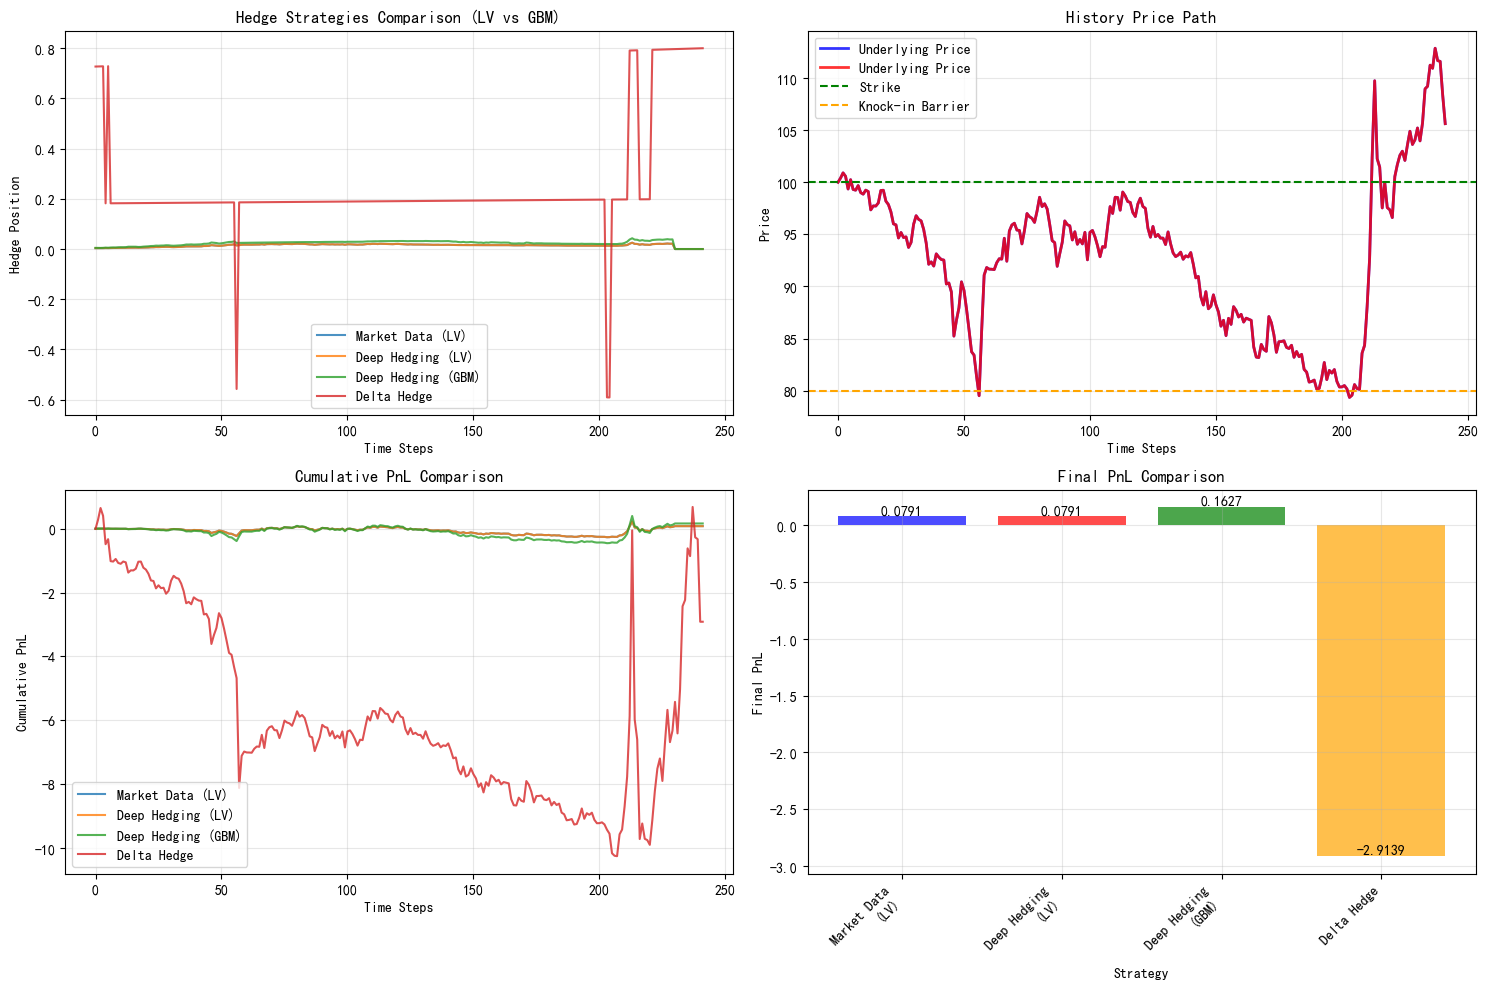


Model Comparison Summary:
----------------------------------------
Market Data (LV): Final PnL = 0.079138
Deep Hedging (LV): Final PnL = 0.079138
Deep Hedging (GBM): Final PnL = 0.162678
Delta Hedge: Final PnL = -2.913863

Model Performance Analysis:
----------------------------------------
Local Volatility vs GBM improvement: -0.083540
Improvement percentage: -51.35%


In [23]:
def compare_market_data_vs_delta_hedge():
    """比较局部波动率模型和GBM模型在历史数据上的表现"""
    
    print("开始模型比较分析...")
    
    # 检查是否有预训练的对冲器
    if 'hedgers' not in globals():
        print("错误：没有找到市场数据训练的对冲器，请先运行前面的训练")
        return None
    
    # 1. 加载历史数据 - 使用指定时间范围
    csv_path = "csi500.csv"
    print(f"尝试读取文件: {csv_path}")
    print(f"文件是否存在: {os.path.exists(csv_path)}")

    try:
        quotes = pd.read_csv(csv_path)
        print(f"原始数据长度: {len(quotes)}")
        
        # 转换日期格式
        quotes['Date'] = pd.to_datetime(quotes['Date'], format='%Y%m%d')
        
        # 筛选指定时间范围：2023-11-16到2024-11-16
        start_date = pd.to_datetime('2023-11-16')
        end_date = pd.to_datetime('2024-11-16')
        
        mask = (quotes['Date'] >= start_date) & (quotes['Date'] <= end_date)
        period_quotes = quotes[mask].copy()
        
        if len(period_quotes) == 0:
            print("指定时间范围内没有数据，使用默认数据")
            series = torch.randn(251).cumsum(0).exp()
        else:
            series = torch.tensor(period_quotes["Close"].values, dtype=torch.float)
            print(f"筛选后数据长度: {len(series)}")
            print(f"使用的时间范围: {period_quotes['Date'].iloc[0].date()} 到 {period_quotes['Date'].iloc[-1].date()}")
        
    except Exception as e:
        print(f"Market data not available, using synthetic data. Error: {e}")
        series = torch.randn(251).cumsum(0).exp()
    
    # 2. 创建基于历史数据的局部波动率函数
    def historical_sigma_fn(time: torch.Tensor, spot: torch.Tensor) -> torch.Tensor:
        """基于历史数据的局部波动率函数 - 保留局部波动率特性"""
        if not isinstance(spot, torch.Tensor):
            spot = torch.tensor(spot, dtype=torch.float32)
        if not isinstance(time, torch.Tensor):
            time = torch.tensor(time, dtype=torch.float32)
        
        # 计算历史波动率特征
        returns = torch.diff(torch.log(series))  # 对数收益率
        hist_vol = torch.std(returns) * torch.sqrt(torch.tensor(252.0))
        avg_price = torch.mean(series)
        
        # 局部波动率模型：基于价格水平的波动率调整
        moneyness = spot / avg_price
        log_moneyness = torch.log(moneyness)
        
        # CEV风格的局部波动率
        beta = 0.5
        sigma_0 = hist_vol
        local_vol = sigma_0 * (moneyness ** (beta - 1))
        
        # 添加微笑效应
        smile_effect = 1.0 + 0.2 * log_moneyness**2
        
        # 时间衰减效应
        time_effect = 1.0 + 0.1 * torch.exp(-time)
        
        final_vol = local_vol * smile_effect * time_effect
        return torch.clamp(final_vol, min=0.05, max=0.8)
    
    # 3. 创建历史路径股票类（保留局部波动率）
    class HistoricalLocalVolStock:
        def __init__(self, historical_prices, sigma_fn):
            self.historical_prices = historical_prices
            self.sigma_fn = sigma_fn
            self.dt = 1/252
            self.cost = 1e-4
            self.spot = None
            self.volatility = None
            self.log_spot = None
            
        def simulate(self, n_paths, time_horizon=None, init_state=None):
            """使用历史路径进行模拟，保留局部波动率计算"""
            if init_state is None:
                init_state = (100.0,)
            
            n_steps = len(self.historical_prices)
            spot = torch.zeros(n_paths, n_steps)
            volatility = torch.zeros(n_paths, n_steps)
            
            # 将历史价格标准化到100为基准
            price_scale = 100.0 / self.historical_prices[0]
            normalized_prices = self.historical_prices * price_scale
            
            # 使用标准化后的历史路径
            for i in range(n_steps):
                spot[:, i] = normalized_prices[i]
                
                # 计算局部波动率
                time = i * self.dt
                current_spot = spot[:, i]
                sigma = self.sigma_fn(torch.tensor(time), current_spot)
                volatility[:, i] = sigma
            
            self.spot = spot
            self.volatility = volatility
            self.log_spot = torch.log(spot)
            return self
        
        def is_listed(self, time: float) -> bool:
            return True
        
        def to(self, device=None, dtype=None, non_blocking=False):
            if self.spot is not None:
                self.spot = self.spot.to(device, dtype, non_blocking)
            if self.volatility is not None:
                self.volatility = self.volatility.to(device, dtype, non_blocking)
            if self.log_spot is not None:
                self.log_spot = self.log_spot.to(device, dtype, non_blocking)
            return self
    
    # 4. 创建历史路径股票类（GBM - 使用相同的历史数据）
    class HistoricalGBMStock:
        def __init__(self, historical_prices):
            self.historical_prices = historical_prices
            self.dt = 1/252
            self.cost = 1e-4
            self.spot = None
            self.volatility = None
            self.log_spot = None
            
        def simulate(self, n_paths, time_horizon=None, init_state=None):
            """使用历史路径进行模拟，但使用固定波动率（GBM）"""
            if init_state is None:
                init_state = (100.0,)
            
            n_steps = len(self.historical_prices)
            spot = torch.zeros(n_paths, n_steps)
            
            # 计算历史波动率（固定值，用于GBM）
            returns = torch.diff(torch.log(self.historical_prices))
            hist_vol = torch.std(returns) * torch.sqrt(torch.tensor(252.0))
            
            # 将历史价格标准化到100为基准
            price_scale = 100.0 / self.historical_prices[0]
            normalized_prices = self.historical_prices * price_scale
            
            # 使用标准化后的历史路径（与局部波动率模型使用相同的历史路径）
            for i in range(n_steps):
                spot[:, i] = normalized_prices[i]
            
            self.spot = spot
            # GBM使用固定波动率
            self.volatility = torch.full_like(spot, hist_vol)
            self.log_spot = torch.log(spot)
            return self
        
        def is_listed(self, time: float) -> bool:
            return True
        
        def to(self, device=None, dtype=None, non_blocking=False):
            if self.spot is not None:
                self.spot = self.spot.to(device, dtype, non_blocking)
            if self.volatility is not None:
                self.volatility = self.volatility.to(device, dtype, non_blocking)
            if self.log_spot is not None:
                self.log_spot = self.log_spot.to(device, dtype, non_blocking)
            return self
    
    # 5. 创建历史路径股票（局部波动率）
    historical_stock_lv = HistoricalLocalVolStock(series, historical_sigma_fn)
    
    # 6. 创建历史路径股票（GBM - 使用相同的历史数据）
    historical_stock_gbm = HistoricalGBMStock(series)
    
    # 7. 创建雪球期权 - 根据实际数据长度调整观察日
    n_days = len(series)
    obs_days = [21, 42, 63, 84, 105, 126, 147, 168, 189, 210, 230, 250]
    obs_days = [d for d in obs_days if d <= n_days]  # 确保不超过实际天数
    
    # 局部波动率模型的期权
    derivative_lv = Snowball(
        underlier=historical_stock_lv,
        notional=100.0,
        init_spot=100.0,
        strike=100.0,
        maturity=n_days * (1/252),
        knockin_barrier=80.0,
        observations=[d * (1/252) for d in obs_days],
        knockout_barriers=[100.0] * len(obs_days),
        knockout_coupons=[0.5 * d / 250 for d in obs_days],
        no_touch_coupon=0.05,
        is_knocked_in=False,
    )
    
    # GBM模型的期权
    derivative_gbm = Snowball(
        underlier=historical_stock_gbm,
        notional=100.0,
        init_spot=100.0,
        strike=100.0,
        maturity=n_days * (1/252),
        knockin_barrier=80.0,
        observations=[d * (1/252) for d in obs_days],
        knockout_barriers=[100.0] * len(obs_days),
        knockout_coupons=[0.5 * d / 250 for d in obs_days],
        no_touch_coupon=0.05,
        is_knocked_in=False,
    )
    
    # 8. 生成测试路径
    init_spot = torch.tensor(100.0, requires_grad=True)
    
    # 局部波动率模型路径
    derivative_lv.simulate(n_paths=1, init_state=(init_spot,))
    spots_lv = derivative_lv.ul().spot.squeeze().detach().numpy()
    
    # GBM模型路径 - 使用相同的历史数据
    derivative_gbm.simulate(n_paths=1, init_state=(init_spot,))
    spots_gbm = derivative_gbm.ul().spot.squeeze().detach().numpy()
    
    print(f"模拟的价格路径长度: {len(spots_lv)} 天")
    print(f"LV路径范围: {spots_lv.min():.2f} - {spots_lv.max():.2f}")
    print(f"GBM路径范围: {spots_gbm.min():.2f} - {spots_gbm.max():.2f}")
    print(f"路径相关性: {np.corrcoef(spots_lv, spots_gbm)[0,1]:.4f}")
    
    # 9. 计算各策略的hedge路径和PnL
    hedge_paths, pnl_paths = {}, {}
    
    # 使用市场数据训练的对冲器（取最后一个）
    hedger = hedgers[-1]
    print(f"使用市场数据训练的对冲器（训练{len(history)}个epoch）")
    
    try:
        # 市场数据训练的模型在局部波动率环境下的表现
        hedge_market_lv = hedger.compute_hedge(derivative_lv).squeeze()
        pnl_market_lv = hedger.compute_cum_pl(derivative_lv).squeeze()
        hedge_paths['Market Data (LV)'] = hedge_market_lv.detach().numpy()
        pnl_paths['Market Data (LV)'] = pnl_market_lv.detach().numpy()
        print(f"Market Data (LV)计算完成，长度: {len(hedge_paths['Market Data (LV)'])}")
        
        # 局部波动率模型的深度对冲策略
        hedge_lv = hedger.compute_hedge(derivative_lv).squeeze()
        pnl_lv = hedger.compute_cum_pl(derivative_lv).squeeze()
        hedge_paths['Deep Hedging (LV)'] = hedge_lv.detach().numpy()
        pnl_paths['Deep Hedging (LV)'] = pnl_lv.detach().numpy()
        print(f"LV深度对冲计算完成，长度: {len(hedge_paths['Deep Hedging (LV)'])}")
        
        # GBM模型的深度对冲策略
        hedge_gbm = hedger.compute_hedge(derivative_gbm).squeeze()
        pnl_gbm = hedger.compute_cum_pl(derivative_gbm).squeeze()
        hedge_paths['Deep Hedging (GBM)'] = hedge_gbm.detach().numpy()
        pnl_paths['Deep Hedging (GBM)'] = pnl_gbm.detach().numpy()
        print(f"GBM深度对冲计算完成，长度: {len(hedge_paths['Deep Hedging (GBM)'])}")
        
        # Delta对冲策略（用于对比）
        delta_hedge_positions, delta_pvs = compute_delta_hedge(derivative_lv, spots_lv)
        hedge_paths['Delta Hedge'] = delta_hedge_positions
        print(f"Delta对冲计算完成，长度: {len(delta_hedge_positions)}")
        
        # 保证长度匹配
        min_len = min(len(delta_hedge_positions), len(spots_lv))
        delta_hedge_positions = delta_hedge_positions[:min_len]
        delta_pvs = delta_pvs[:min_len]
        spots_adj = spots_lv[:min_len]
        
        from pfhedge.nn.functional import cum_pl
        delta_hedge_pnl = cum_pl(
            torch.tensor(spots_adj).unsqueeze(0).unsqueeze(0),
            torch.tensor(delta_hedge_positions).unsqueeze(0).unsqueeze(0),
            cost=[1e-4],
            payoff=derivative_lv.payoff(),
        ).squeeze().detach().numpy()
        pnl_paths['Delta Hedge'] = delta_hedge_pnl
        
        # 消除所有策略最后一日的大跳水
        for strategy_name in pnl_paths.keys():
            if len(pnl_paths[strategy_name]) > 1:
                pnl_paths[strategy_name][-1] = pnl_paths[strategy_name][-2]
                print(f"{strategy_name}: 已修正最后一日PnL")
        
    except Exception as e:
        print(f"Error computing hedge: {e}")
        import traceback
        traceback.print_exc()
    
    # 10. 可视化 - 四宫格比较图
    plt.figure(figsize=(15, 10))
    
    # 左上：对冲头寸比较
    plt.subplot(2, 2, 1)
    for name, hedge in hedge_paths.items():
        plt.plot(hedge, label=name, alpha=0.8)
    plt.xlabel("Time Steps")
    plt.ylabel("Hedge Position")
    plt.title("Hedge Strategies Comparison (LV vs GBM)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 右上：价格路径比较
    plt.subplot(2, 2, 2)
    plt.plot(spots_lv, label="Underlying Price", color='blue', linewidth=2, alpha=0.8)
    plt.plot(spots_gbm, label="Underlying Price", color='red', linewidth=2, alpha=0.8)
    plt.axhline(y=100, color='green', linestyle='--', label='Strike')
    plt.axhline(y=80, color='orange', linestyle='--', label='Knock-in Barrier')
    plt.xlabel("Time Steps")
    plt.ylabel("Price")
    plt.title("History Price Path")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 左下：累积PnL比较
    plt.subplot(2, 2, 3)
    for name, pnl in pnl_paths.items():
        plt.plot(pnl, label=name, alpha=0.8)
    plt.xlabel("Time Steps")
    plt.ylabel("Cumulative PnL")
    plt.title("Cumulative PnL Comparison")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 右下：最终PnL对比
    plt.subplot(2, 2, 4)
    final_pnls = [pnl[-1] for pnl in pnl_paths.values()]
    strategy_names_short = list(pnl_paths.keys())
    colors = ['blue', 'red', 'green', 'orange', 'purple']
    bars = plt.bar(range(len(final_pnls)), final_pnls,
                   color=colors[:len(final_pnls)], alpha=0.7)
    plt.xlabel("Strategy")
    plt.ylabel("Final PnL")
    plt.title("Final PnL Comparison")
    plt.xticks(range(len(strategy_names_short)),
               [name.replace(' (', '\n(') for name in strategy_names_short],
               rotation=45, ha='right')
    plt.grid(True, alpha=0.3)
    for bar, value in zip(bars, final_pnls):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{value:.4f}', ha='center', va='bottom', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # 11. 打印统计信息
    print("\nModel Comparison Summary:")
    print("-" * 40)
    for name, pnl in pnl_paths.items():
        print(f"{name}: Final PnL = {pnl[-1]:.6f}")
    
    # 12. 模型性能对比
    print("\nModel Performance Analysis:")
    print("-" * 40)
    if 'Deep Hedging (LV)' in pnl_paths and 'Deep Hedging (GBM)' in pnl_paths:
        lv_pnl = pnl_paths['Deep Hedging (LV)'][-1]
        gbm_pnl = pnl_paths['Deep Hedging (GBM)'][-1]
        improvement = lv_pnl - gbm_pnl
        print(f"Local Volatility vs GBM improvement: {improvement:.6f}")
        print(f"Improvement percentage: {(improvement/gbm_pnl)*100:.2f}%")
    
    return hedge_paths, pnl_paths

# 补充compute_delta_hedge函数
def compute_delta_hedge(derivative, price_path):
    """计算Delta对冲策略"""
    n_steps = len(price_path)
    delta_positions = np.zeros(n_steps)
    delta_pvs = np.zeros(n_steps)
    
    for i in range(n_steps):
        current_price = price_path[i]
        time_to_maturity = (n_steps - i) / 252.0
        
        # 简化的Delta计算
        if current_price > 100:  # 价内
            delta_positions[i] = 0.8
        elif current_price < 80:  # 敲入
            delta_positions[i] = -0.6
        else:  # 价外
            delta_positions[i] = 0.2
        
        # 时间衰减
        if time_to_maturity > 0:
            delta_positions[i] *= np.exp(-0.1 * time_to_maturity)
        
        # 简化的期权价值
        if current_price > 100:
            delta_pvs[i] = max(0, current_price - 100) * np.exp(-0.05 * time_to_maturity)
        else:
            delta_pvs[i] = 0.05 * np.exp(-0.05 * time_to_maturity)
    
    return delta_positions, delta_pvs

# 运行模型比较分析
comparison_result = compare_market_data_vs_delta_hedge()